# cs_veg sweep: 3D vs 1D LWP

Three diagnostics across all five cs_veg values:
1. **Mean 3D - 1D LWP** timeseries (g m-2)
2. **Normalised 3D - 1D LWP** timeseries ((3D - 1D) / 1D)
3. **Time integral** of 3D - 1D LWP over the cloudy period (g m-2 h)

In [1]:
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from cass_analysis import (
    load_stats,
    lwp_integral,
    lwp_normalized_diff,
    _to_plottime,
)
from catalog import list_group, make_runset

In [2]:
N_REPS = 4
sweep  = list_group("cs_veg")   # [(key, meta), ...] sorted by param
params = [meta["param"] for _, meta in sweep]

# Colour ramp: log-spaced over non-zero values, grey for cs_veg=0
nonzero = [p for p in params if p > 0]
_norm = mcolors.LogNorm(vmin=min(nonzero), vmax=max(nonzero))
_cmap = cm.plasma_r

def get_color(i):
    return "0.5" if params[i] == 0 else _cmap(_norm(params[i]))

print("cs_veg keys:", [k for k, _ in sweep])

cs_veg keys: ['cs_veg_0', 'cs_veg_41840', 'cs_veg_418400', 'cs_veg_4184000', 'cs_veg_41840000']


In [3]:
results = []

for key, meta in sweep:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rs      = make_runset(key, n_reps=N_REPS)
        dirs_2s = rs.dirs.get("2stream", [])
        dirs_rt = rs.dirs.get("raytracer", [])

    if not dirs_2s or not dirs_rt:
        print(f"  [{key}] missing reps, skipping")
        continue

    reps_2s = [load_stats(d) for d in dirs_2s]
    reps_rt = [load_stats(d) for d in dirs_rt]

    n_paired = min(len(reps_2s), len(reps_rt))
    nt = min(*(s["qlqi_path"].shape[0] for s in reps_2s + reps_rt))

    lwp_1d_reps = np.stack([s["qlqi_path"][:nt] * 1e3 for s in reps_2s[:n_paired]])
    lwp_3d_reps = np.stack([s["qlqi_path"][:nt] * 1e3 for s in reps_rt[:n_paired]])
    diff_reps   = lwp_3d_reps - lwp_1d_reps

    lwp_1d     = lwp_1d_reps.mean(axis=0)
    lwp_3d     = lwp_3d_reps.mean(axis=0)
    lwp_1d_std = lwp_1d_reps.std(axis=0, ddof=0)
    lwp_3d_std = lwp_3d_reps.std(axis=0, ddof=0)
    diff       = diff_reps.mean(axis=0)
    diff_std   = diff_reps.std(axis=0, ddof=0)

    norm_reps     = lwp_normalized_diff(diff_reps, lwp_1d_reps) * 100.0
    norm_diff     = np.nanmean(norm_reps, axis=0)
    norm_diff_std = np.nanstd(norm_reps,  axis=0, ddof=0)

    t_local = reps_2s[0]["t_local"][:nt]
    t_sec   = reps_2s[0]["t_sec"][:nt]
    dt_s    = float(t_sec[1] - t_sec[0]) if len(t_sec) > 1 else 60.0

    cloudy_mask = (lwp_1d > 0.1) | (lwp_3d > 0.1)
    has_cloud   = bool(cloudy_mask.any())

    def _norm_integral_rep(r):
        vals = norm_reps[r][cloudy_mask]
        return float(np.nansum(vals) * dt_s / 3600.0)

    if has_cloud:
        integral     = lwp_integral(diff, dt_s, cloudy_mask=cloudy_mask)
        integral_std = float(np.std(
            [lwp_integral(diff_reps[r], dt_s, cloudy_mask=cloudy_mask)
             for r in range(n_paired)], ddof=0))
        norm_integral = float(np.nansum(norm_diff[cloudy_mask]) * dt_s / 3600.0)
        norm_integral_std = float(np.std(
            [_norm_integral_rep(r) for r in range(n_paired)], ddof=0))
    else:
        integral = integral_std = np.nan
        norm_integral = norm_integral_std = np.nan

    results.append(dict(
        key=key, label=meta["label"],
        t_local=t_local,
        lwp_1d=lwp_1d, lwp_1d_std=lwp_1d_std,
        lwp_3d=lwp_3d, lwp_3d_std=lwp_3d_std,
        diff=diff, diff_std=diff_std,
        norm_diff=norm_diff, norm_diff_std=norm_diff_std,
        integral=integral, integral_std=integral_std,
        norm_integral=norm_integral, norm_integral_std=norm_integral_std,
        has_cloud=has_cloud, n_paired=n_paired,
    ))

    int_str  = f"{integral:+7.2f} +/- {integral_std:.2f} g m-2 h" if has_cloud else "n/a (no cloud yet)"
    nint_str = f"{norm_integral:+7.2f} +/- {norm_integral_std:.2f} % h" if has_cloud else "n/a"
    print(f"{key:25s}  integral = {int_str}   norm integral = {nint_str}")

print(f"\n{len(results)} conditions loaded.")

/tmp/ipykernel_26332/3232051577.py:32: RuntimeWarning: Mean of empty slice
  norm_diff     = np.nanmean(norm_reps, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


cs_veg_0                   integral =  +27.06 +/- 1.46 g m-2 h   norm integral = +536.89 +/- 48.24 % h


/tmp/ipykernel_26332/3232051577.py:32: RuntimeWarning: Mean of empty slice
  norm_diff     = np.nanmean(norm_reps, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


cs_veg_41840               integral =  +27.17 +/- 1.26 g m-2 h   norm integral = +480.61 +/- 49.52 % h


/tmp/ipykernel_26332/3232051577.py:32: RuntimeWarning: Mean of empty slice
  norm_diff     = np.nanmean(norm_reps, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


cs_veg_418400              integral =  +19.39 +/- 1.20 g m-2 h   norm integral = +238.34 +/- 19.59 % h


/tmp/ipykernel_26332/3232051577.py:32: RuntimeWarning: Mean of empty slice
  norm_diff     = np.nanmean(norm_reps, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


cs_veg_4184000             integral = n/a (no cloud yet)   norm integral = n/a
cs_veg_41840000            integral = n/a (no cloud yet)   norm integral = n/a

5 conditions loaded.


/tmp/ipykernel_26332/3232051577.py:32: RuntimeWarning: Mean of empty slice
  norm_diff     = np.nanmean(norm_reps, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


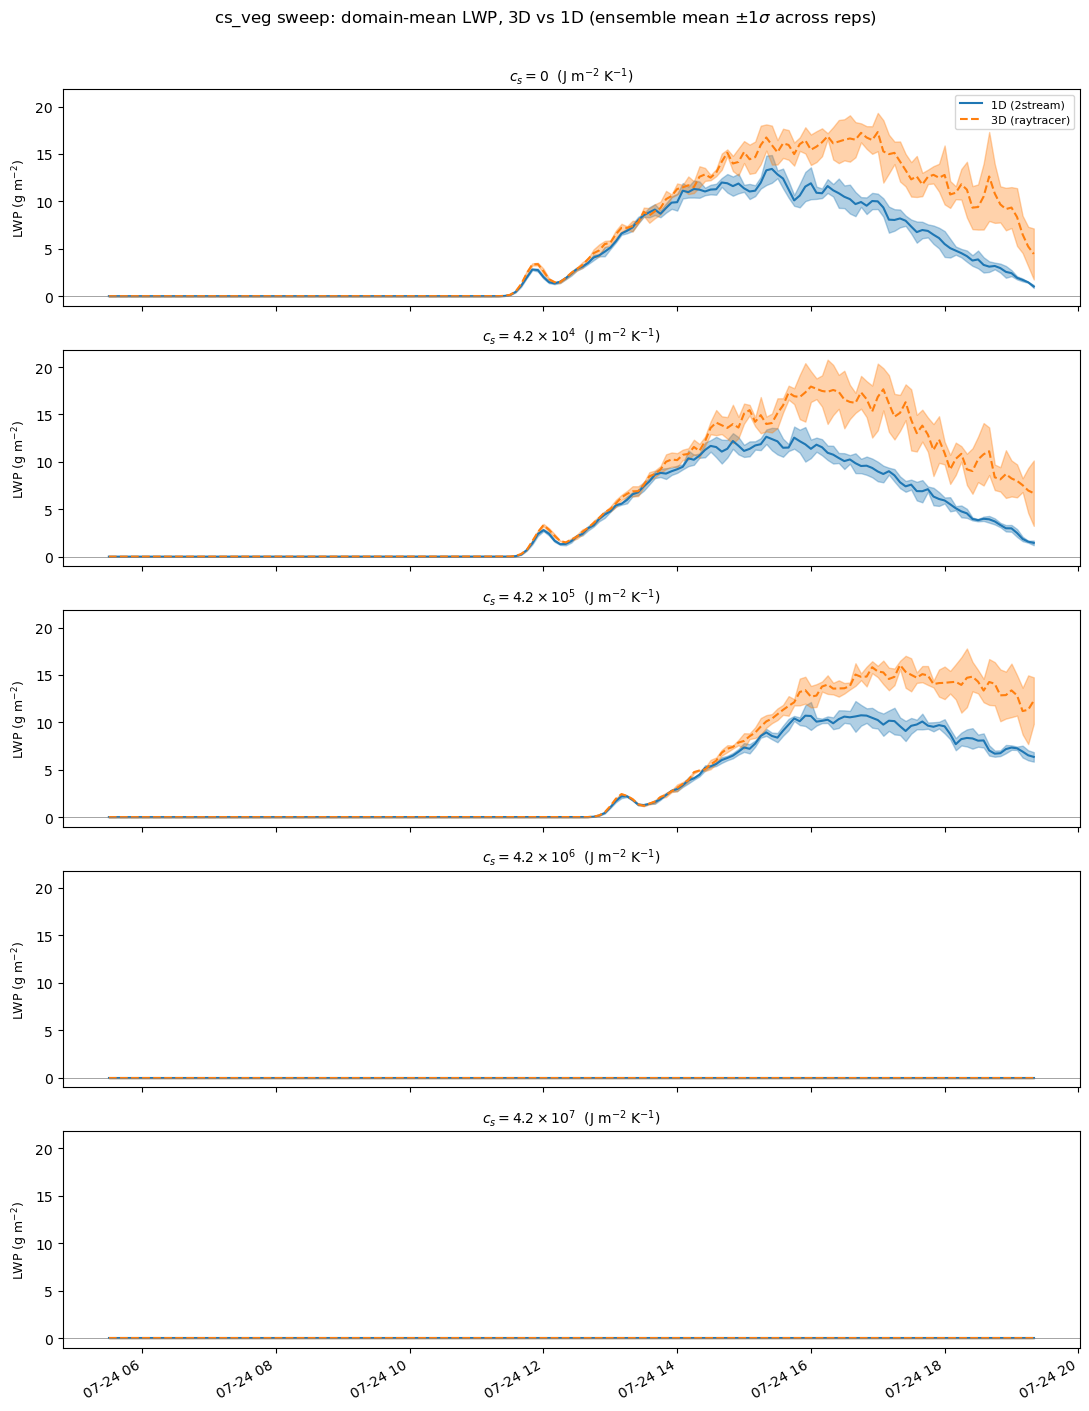

Saved lwp_cs_veg_timeseries.pdf


In [4]:
fig, axes = plt.subplots(len(results), 1, figsize=(11, 2.8 * len(results)),
                         sharex=True, sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, r, i in zip(axes, results, range(len(results))):
    t_num = _to_plottime(r["t_local"])

    ax.plot(t_num, r["lwp_1d"], color="C0", ls="-",  lw=1.5, label="1D (2stream)")
    ax.fill_between(t_num,
                    r["lwp_1d"] - r["lwp_1d_std"],
                    r["lwp_1d"] + r["lwp_1d_std"],
                    color="C0", alpha=0.35)

    ax.plot(t_num, r["lwp_3d"], color="C1", ls="--", lw=1.5, label="3D (raytracer)")
    ax.fill_between(t_num,
                    r["lwp_3d"] - r["lwp_3d_std"],
                    r["lwp_3d"] + r["lwp_3d_std"],
                    color="C1", alpha=0.35)

    ax.set_ylabel(r"LWP (g m$^{-2}$)", fontsize=9)
    ax.set_title(r["label"] + r"  (J m$^{-2}$ K$^{-1}$)", fontsize=10)
    ax.axhline(0, color="gray", lw=0.5)
    ax.xaxis_date()
    ax.figure.autofmt_xdate()
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle(r"cs_veg sweep: domain-mean LWP, 3D vs 1D (ensemble mean $\pm 1\sigma$ across reps)",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig("lwp_cs_veg_timeseries.pdf", bbox_inches="tight")
plt.show()
print("Saved lwp_cs_veg_timeseries.pdf")

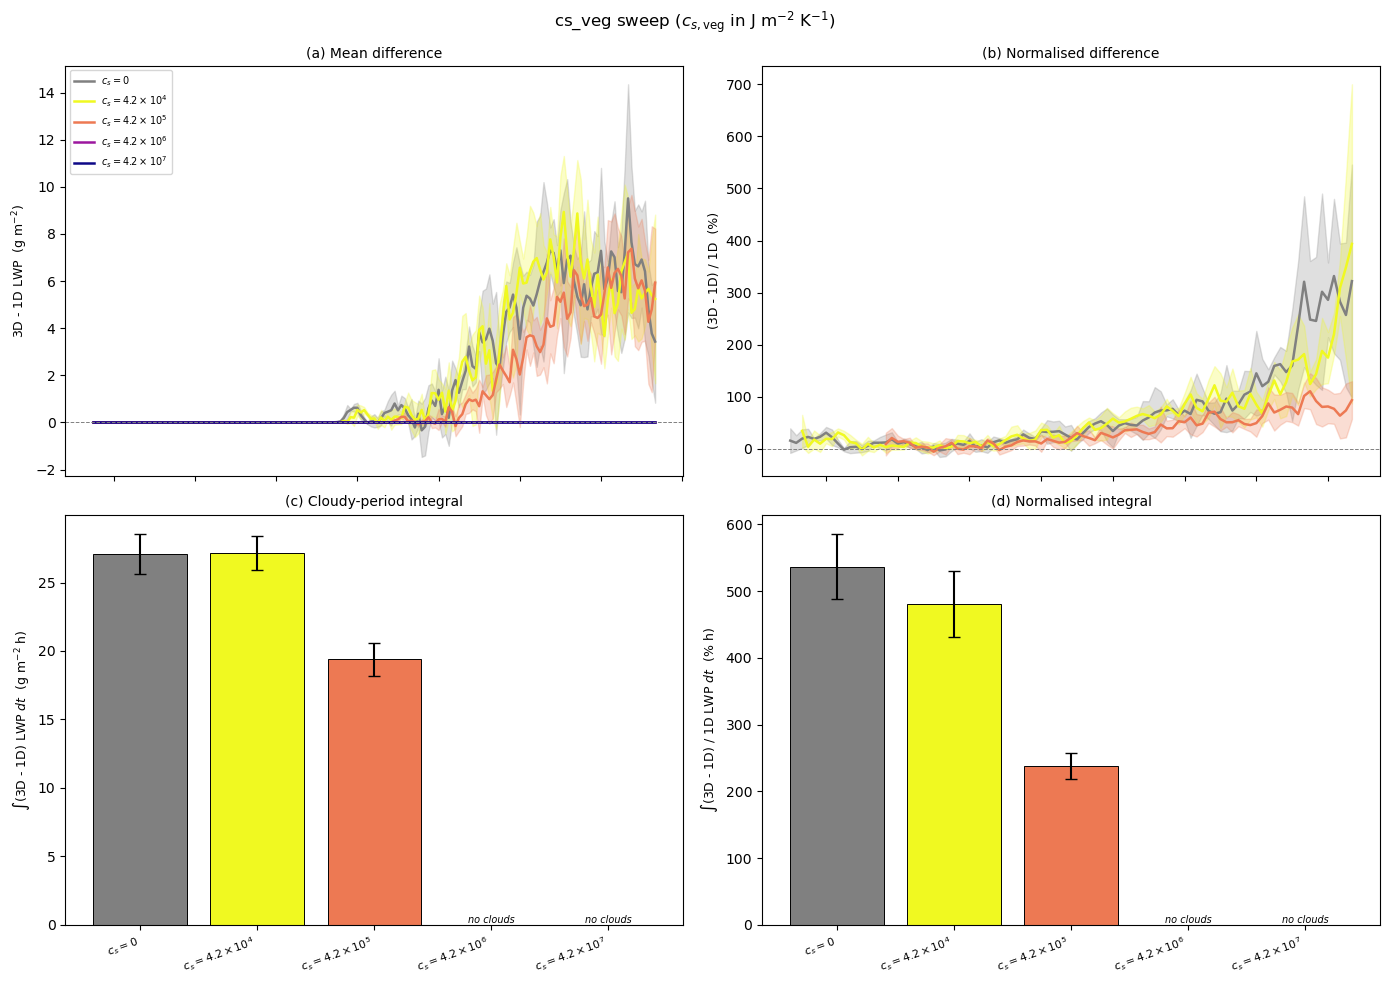

Saved lwp_cs_veg_summary.pdf


In [5]:
integrals          = [r["integral"]          for r in results]
integral_stds      = [r["integral_std"]      for r in results]
norm_integrals     = [r["norm_integral"]     for r in results]
norm_integral_stds = [r["norm_integral_std"] for r in results]
labels             = [r["label"]             for r in results]
x_pos              = np.arange(len(results))
bar_colors         = [get_color(i) for i in range(len(results))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_diff = axes[0, 0]
ax_norm = axes[0, 1]
ax_int  = axes[1, 0]
ax_nint = axes[1, 1]

# ── (a) mean diff +/- 1 sigma ────────────────────────────────────────────────
for r, i in zip(results, range(len(results))):
    t_num = _to_plottime(r["t_local"])
    c     = get_color(i)
    ax_diff.plot(t_num, r["diff"], color=c, lw=1.8, label=r["label"])
    ax_diff.fill_between(t_num,
                         r["diff"] - r["diff_std"],
                         r["diff"] + r["diff_std"],
                         color=c, alpha=0.25)
ax_diff.axhline(0, color="gray", lw=0.7, ls="--")
ax_diff.set_ylabel(r"3D - 1D LWP  (g m$^{-2}$)", fontsize=9)
ax_diff.set_title("(a) Mean difference", fontsize=10)
ax_diff.legend(fontsize=7, loc="upper left")
ax_diff.xaxis_date()
ax_diff.figure.autofmt_xdate()

# ── (b) normalised diff +/- 1 sigma ─────────────────────────────────────────
for r, i in zip(results, range(len(results))):
    t_num = _to_plottime(r["t_local"])
    c     = get_color(i)
    ax_norm.plot(t_num, r["norm_diff"], color=c, lw=1.8)
    ax_norm.fill_between(t_num,
                         r["norm_diff"] - r["norm_diff_std"],
                         r["norm_diff"] + r["norm_diff_std"],
                         color=c, alpha=0.25)
ax_norm.axhline(0, color="gray", lw=0.7, ls="--")
ax_norm.set_ylabel("(3D - 1D) / 1D  (%)", fontsize=9)
ax_norm.set_title("(b) Normalised difference", fontsize=10)
ax_norm.xaxis_date()
ax_norm.figure.autofmt_xdate()

# ── (c) integral bar chart +/- 1 sigma ───────────────────────────────────────
for x, val, err, c in zip(x_pos, integrals, integral_stds, bar_colors):
    if np.isnan(val):
        ax_int.bar(x, 0, color=c, edgecolor="k", lw=0.7, hatch="//", alpha=0.4)
        ax_int.text(x, 0.01, "no clouds", ha="center", va="bottom",
                    fontsize=7, style="italic")
    else:
        ax_int.bar(x, val, color=c, edgecolor="k", lw=0.7)
        ax_int.errorbar(x, val, yerr=err, fmt="none", color="k", capsize=4, lw=1.5)
ax_int.axhline(0, color="gray", lw=0.7)
ax_int.set_xticks(x_pos)
ax_int.set_xticklabels(labels, fontsize=8, rotation=20, ha="right")
ax_int.set_ylabel(r"$\int$(3D - 1D) LWP $dt$  (g m$^{-2}$ h)", fontsize=9)
ax_int.set_title("(c) Cloudy-period integral", fontsize=10)

# ── (d) normalised integral bar chart +/- 1 sigma ────────────────────────────
for x, val, err, c in zip(x_pos, norm_integrals, norm_integral_stds, bar_colors):
    if np.isnan(val):
        ax_nint.bar(x, 0, color=c, edgecolor="k", lw=0.7, hatch="//", alpha=0.4)
        ax_nint.text(x, 0.01, "no clouds", ha="center", va="bottom",
                     fontsize=7, style="italic")
    else:
        ax_nint.bar(x, val, color=c, edgecolor="k", lw=0.7)
        ax_nint.errorbar(x, val, yerr=err, fmt="none", color="k", capsize=4, lw=1.5)
ax_nint.axhline(0, color="gray", lw=0.7)
ax_nint.set_xticks(x_pos)
ax_nint.set_xticklabels(labels, fontsize=8, rotation=20, ha="right")
ax_nint.set_ylabel(r"$\int$(3D - 1D) / 1D LWP $dt$  (% h)", fontsize=9)
ax_nint.set_title("(d) Normalised integral", fontsize=10)

fig.suptitle(r"cs_veg sweep ($c_{s,\mathrm{veg}}$ in J m$^{-2}$ K$^{-1}$)", fontsize=12)
plt.tight_layout()
plt.savefig("lwp_cs_veg_summary.pdf", bbox_inches="tight")
plt.show()
print("Saved lwp_cs_veg_summary.pdf")